# Flappy Bird con Laya: Tutorial Interactivo
### Ingeniería de estado para modelos de decisión System-1

Este notebook acompaña el tutorial escrito. Ejecuta las celdas en orden —
cada una muestra un aspecto distinto del sistema, desde la arquitectura
hasta el resultado final corriendo en GPU.

**No modificarás nada.** Solo ejecutas y observas qué pasa en cada paso.

In [1]:
%matplotlib inline
import os, sys, time, inspect, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from IPython.display import Image, display

warnings.filterwarnings("ignore")

# El notebook vive en la raíz del proyecto — añadir al path
PROJECT_DIR = os.path.abspath(os.getcwd())
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass  # matplotlib < 3.6 fallback

# Verificar dependencias
ok = True
for mod in ["gymnasium", "flappy_bird_gymnasium", "onnxruntime", "tokenizers"]:
    try:
        __import__(mod)
        print(f"  ✓ {mod}")
    except ImportError:
        print(f"  ✗ {mod}  ← pip install {mod}")
        ok = False

if ok:
    print("\nTodas las dependencias están disponibles.")
else:
    print("\nInstala los paquetes faltantes y reinicia el kernel.")

  ✓ gymnasium
  ✓ flappy_bird_gymnasium
  ✓ onnxruntime
  ✓ tokenizers

Todas las dependencias están disponibles.


In [2]:
from engine import LayaJevEngine
from decision_utils import (format_state, question, options,
                             BIRD_X, PIPE_CLEAR_X, GROUND_Y,
                             VEL_SCALE, GRAVITY, FLAP_VEL, MAX_VEL)
import gymnasium

print("Cargando modelo Laya (puede tardar en el primer arranque)...")
engine = LayaJevEngine()

print("\nOpciones de decisión:")
for k, v in options.items():
    print(f"  {k!r}: {v!r}")

Cargando modelo Laya (puede tardar en el primer arranque)...


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 1702.83it/s]


[engine] model=model_fp16.onnx  provider=CPUExecutionProvider

Opciones de decisión:
  'flap': 'Flap wings to rise upward.'
  'no_flap': 'Do not flap; let the bird fall with gravity.'


2026-10-04 10:07:24.920366112 [E:onnxruntime:Default, provider_bridge_ort.cc:2251 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1844 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-10-04 10:07:24.920386330 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:1013 CreateExecutionProviderFactoryInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.


## 1. Arquitectura General

El sistema opera en un **ciclo simple y continuo**:

1. El entorno devuelve `obs[12]` — 12 números normalizados
2. `format_state(obs)` los convierte en texto en lenguaje natural
3. Laya lee ese texto y puntúa dos `[MASK]` tokens (flap / no_flap)
4. Se ejecuta la acción con mayor probabilidad
5. El entorno avanza un frame → nuevo `obs[12]` → volver al paso 1

**No hay aprendizaje por refuerzo. No hay reglas codificadas a mano.**
Solo la descripción del estado es suficiente.

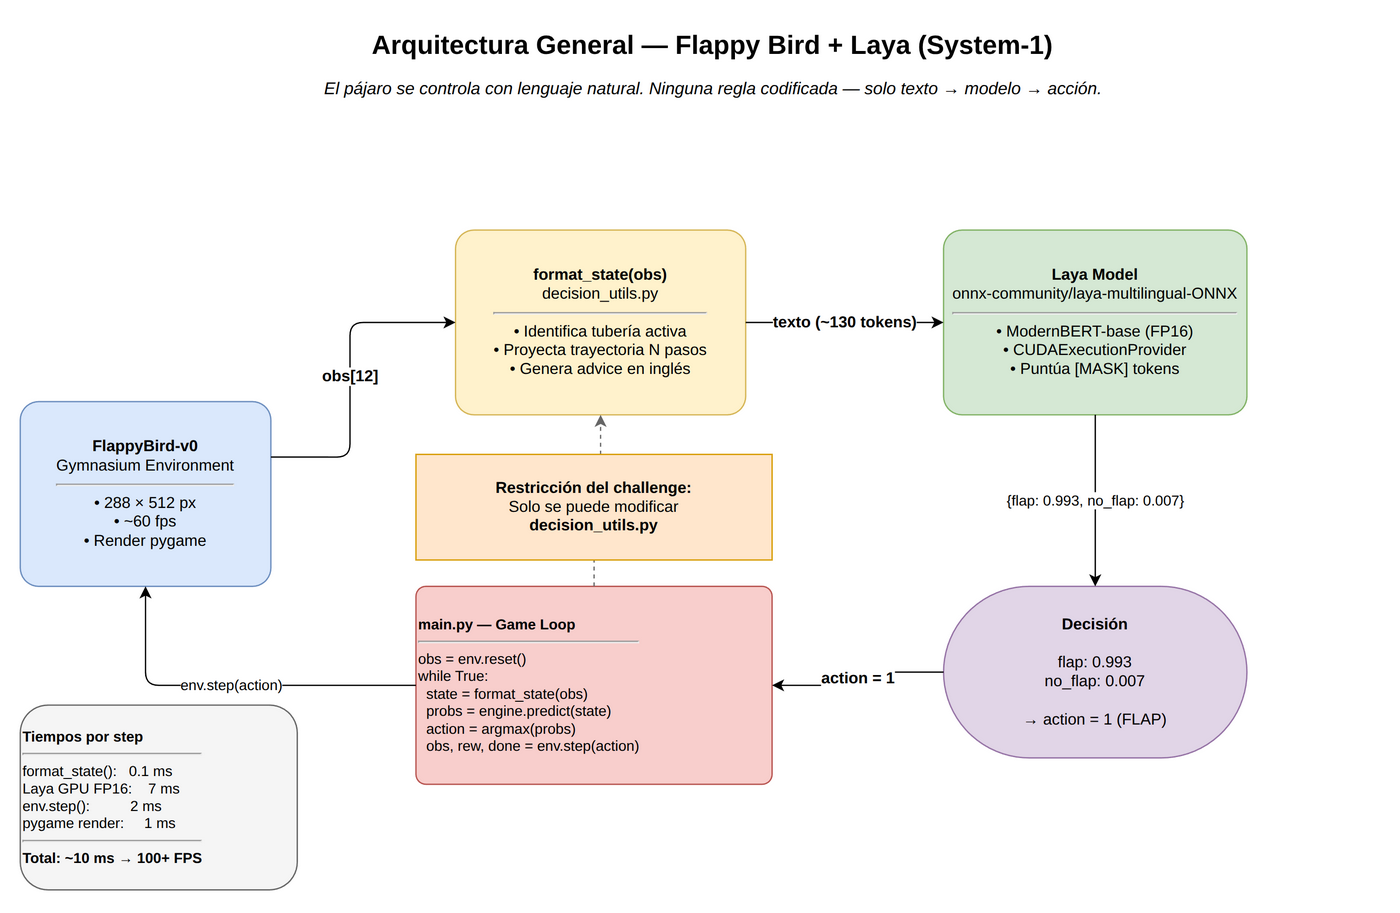

In [3]:
display(Image("diagrams/img/01_arquitectura.png", width=900))

In [4]:
# Un ciclo completo de decisión — vemos cada paso intermedio
env_demo = gymnasium.make("FlappyBird-v0", render_mode="rgb_array")
obs_demo, _ = env_demo.reset()

print("=" * 62)
print("CICLO COMPLETO DE DECISIÓN")
print("=" * 62)

# 1. obs → texto
state_text_demo = format_state(obs_demo)
print(f"\n1. OBSERVACIÓN (obs[12]):")
print(f"   {obs_demo.round(3)}")

print(f"\n2. TEXTO GENERADO (format_state):")
print(f"   {state_text_demo}")

# 2. texto → probabilidades
probs_demo = engine.predict_choice(state_text_demo, question, options)
print(f"\n3. PROBABILIDADES (Laya):")
for k, v in probs_demo.items():
    bar = "█" * int(v * 45)
    print(f"   {k:>10}: {v:.4f}  {bar}")

# 3. decisión
action_demo = 1 if probs_demo["flap"] > probs_demo["no_flap"] else 0
action_name = "FLAP (1)" if action_demo == 1 else "no_flap (0)"
print(f"\n4. ACCIÓN ELEGIDA: {action_name}")

# 4. ejecutar
obs_new_demo, _, _, _, _ = env_demo.step(action_demo)
print(f"\n5. NUEVO ESTADO: y={obs_new_demo[9]:.4f}, vel={obs_new_demo[10]:+.4f}")
env_demo.close()

CICLO COMPLETO DE DECISIÓN

1. OBSERVACIÓN (obs[12]):
   [1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    0.982 0.

## 2. Laya — Modelo System-1

Laya es un modelo **System-1**: produce decisiones en milisegundos sin
cadena de razonamiento. A diferencia de GPT-4 (que piensa paso a paso),
Laya evalúa el contexto de forma directa e intuitiva, como un experto
que actúa por reflejo entrenado.

**Mecanismo:** Laya es un encoder basado en ModernBERT. Recibe la
secuencia completa de tokens. En las posiciones marcadas con `[MASK]`
devuelve un logit (puntuación). El `[MASK]` con mayor logit es la
opción elegida.

```
[CLS] choice question: What is the correct action? [SEP]
[MASK] flap: Flap wings to rise upward.
[MASK] no_flap: Do not flap; let the bird fall with gravity.
[SEP]  Active pipe: dist=0.30 ... Flap now.  [SEP]
        ↑ logit=3.82                ↑ logit=0.21
        prob = 0.993                prob = 0.007
```

El modelo NO genera texto nuevo. Solo puntúa opciones existentes.

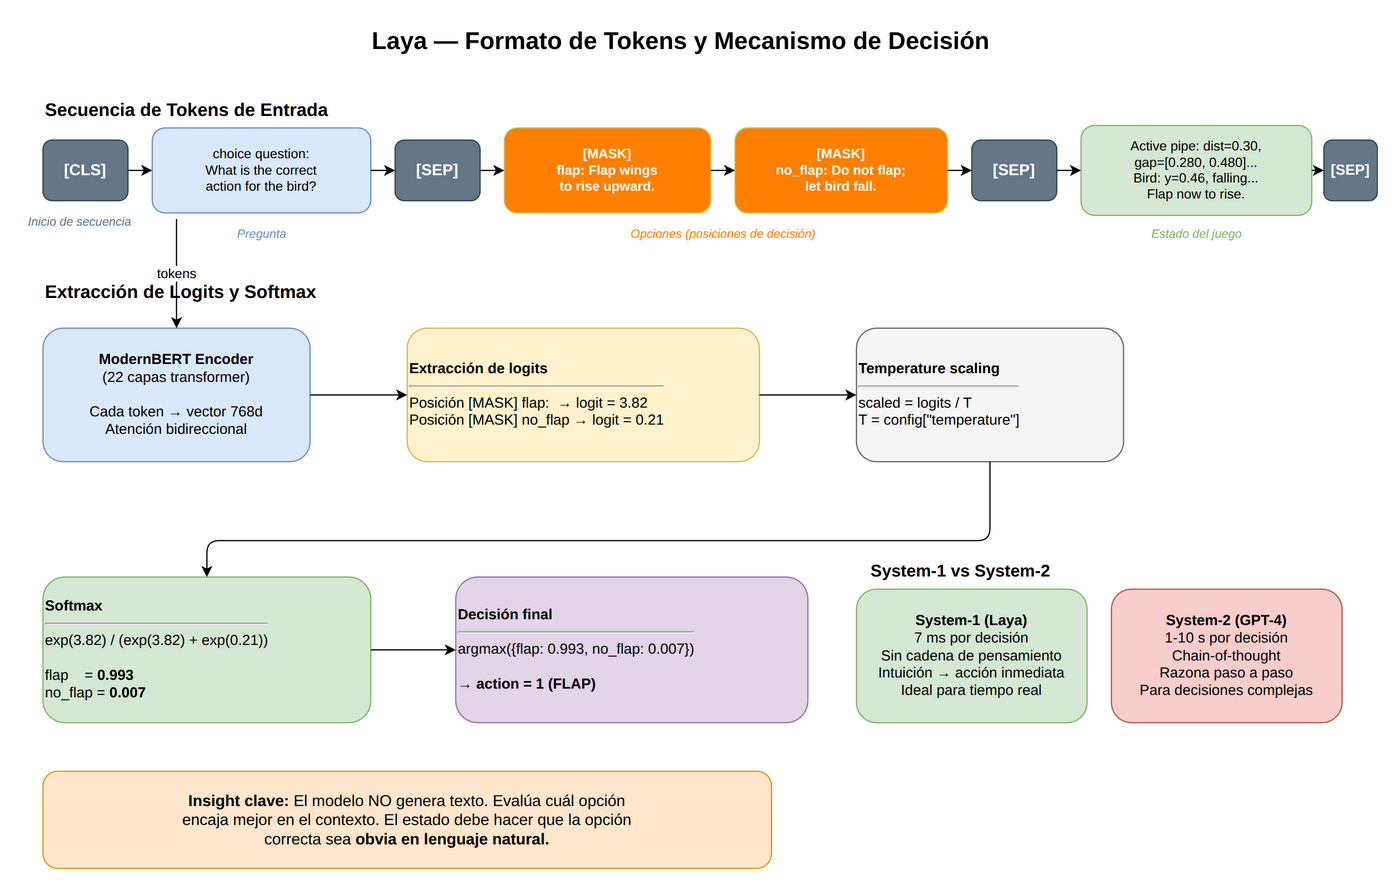

In [5]:
display(Image("diagrams/img/02_laya_tokens.png", width=900))

In [6]:
# Cómo se tokeniza la secuencia de entrada
sample_question = f"choice question: {question}"
q_tokens = engine._tokenize(sample_question)
print(f"Pregunta tokenizada:")
print(f"  Texto  : {sample_question}")
print(f"  Tokens : {q_tokens[:15]}{'...' if len(q_tokens) > 15 else ''}")
print(f"  Longitud: {len(q_tokens)} tokens")

print()
for label, desc in options.items():
    opt_tokens = engine._tokenize(f" {label}: {desc}")
    print(f"Opción '{label}': {len(opt_tokens)} tokens")
    print(f"  Texto  : {label}: {desc}")
    print(f"  Tokens : {opt_tokens[:12]}...")
    print()

example_state = (
    "Active pipe: dist=0.30, gap=[0.280,0.480] (center 0.380). "
    "Bird: y=0.460, falling (vel=+0.90). "
    "No-flap range over 9 steps: [0.460,0.694] — will hit BOTTOM pipe. "
    "Flap now to rise into the gap. Next gap center: 0.500."
)
state_tokens = engine._tokenize(example_state)
print(f"Estado de ejemplo: {len(state_tokens)} tokens")
print(f"  {example_state[:90]}...")

Pregunta tokenizada:
  Texto  : choice question: What is the correct action for the bird right now?
  Tokens : [6241, 2872, 235292, 2439, 603, 573, 5112, 3105, 604, 573, 13170, 1833, 1490, 235336]
  Longitud: 14 tokens

Opción 'flap': 8 tokens
  Texto  : flap: Flap wings to rise upward.
  Tokens : [60945, 235292, 225274, 18751, 577, 9407, 30620, 235265]...

Opción 'no_flap': 15 tokens
  Texto  : no_flap: Do not flap; let the bird fall with gravity.
  Tokens : [793, 235298, 218348, 235292, 2390, 780, 60945, 235289, 2142, 573, 13170, 3881]...

Estado de ejemplo: 99 tokens
  Active pipe: dist=0.30, gap=[0.280,0.480] (center 0.380). Bird: y=0.460, falling (vel=+0.9...


Estado de ejemplo:
  Active pipe: dist=0.30, gap=[0.280,0.480] (center 0.380). Bird: y=0.460, falling (vel=+0.90). No-flap range over 9 steps: [0.460,0.694] — will hit BOTTOM pipe. Flap now to rise into the gap. Next gap center: 0.500.



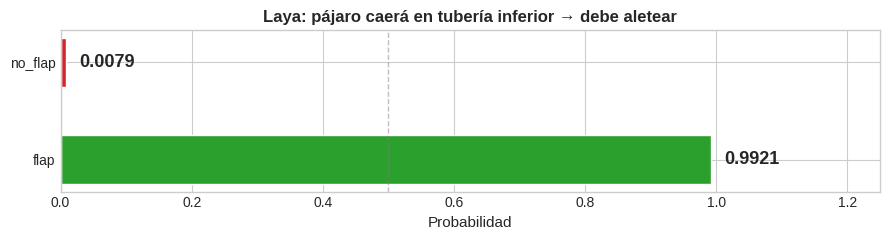

→ Acción: FLAP (confianza 99.2%)


In [7]:
# Predicción sobre un ejemplo concreto de estado
example_state = (
    "Active pipe: dist=0.30, gap=[0.280,0.480] (center 0.380). "
    "Bird: y=0.460, falling (vel=+0.90). "
    "No-flap range over 9 steps: [0.460,0.694] — will hit BOTTOM pipe. "
    "Flap now to rise into the gap. Next gap center: 0.500."
)
probs_ex = engine.predict_choice(example_state, question, options)

print("Estado de ejemplo:")
print(f"  {example_state}\n")

# Visualización
fig, ax = plt.subplots(figsize=(9, 2.5))
labels_p = list(probs_ex.keys())
values_p = [probs_ex[k] for k in labels_p]
colors_p = ["#2ca02c" if k == "flap" else "#d62728" for k in labels_p]

bars = ax.barh(labels_p, values_p, color=colors_p, height=0.5, edgecolor="white")
for bar, val in zip(bars, values_p):
    ax.text(min(val + 0.02, 1.05), bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=13, fontweight="bold")

ax.set_xlim(0, 1.25)
ax.set_xlabel("Probabilidad", fontsize=11)
ax.set_title("Laya: pájaro caerá en tubería inferior → debe aletear", fontsize=12, fontweight="bold")
ax.axvline(0.5, color="gray", ls="--", lw=1, alpha=0.5)
plt.tight_layout()
plt.show()

winner = max(probs_ex, key=probs_ex.get)
print(f"→ Acción: {winner.upper()} (confianza {probs_ex[winner]:.1%})")

## 3. El Entorno — FlappyBird-v0

El entorno es un wrapper **Gymnasium** sobre Flappy Bird. En cada
`env.step(action)` avanza un frame y devuelve una observación de 12
valores normalizados (0..1).

**Sistema de coordenadas — importante:**
- `y = 0` es el **techo** (arriba en pantalla)
- `y = 1` es el **suelo** (abajo en pantalla)
- `y` **aumenta hacia abajo**
- `vel > 0` → cayendo | `vel < 0` → subiendo
- El pájaro tiene posición X **fija** en `x = 0.20`

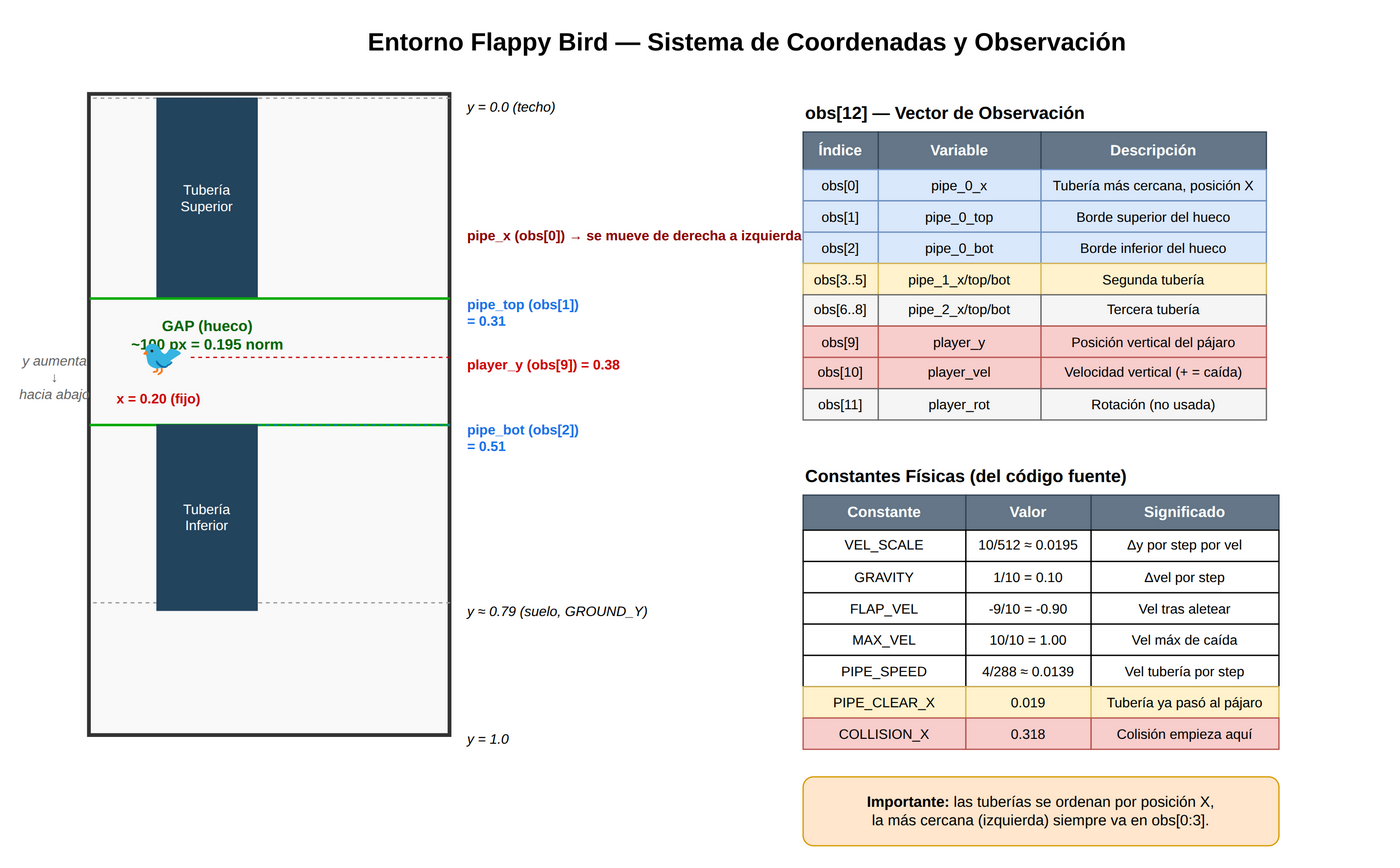

In [8]:
display(Image("diagrams/img/03_entorno_coordenadas.png", width=900))

In [9]:
# Cargar el entorno y explorar obs[12]
env = gymnasium.make("FlappyBird-v0", render_mode="rgb_array")
obs, _ = env.reset()

labels_obs = [
    ("pipe_0_x",   "tubería más cercana — posición X"),
    ("pipe_0_top", "borde superior del hueco"),
    ("pipe_0_bot", "borde inferior del hueco"),
    ("pipe_1_x",   "segunda tubería — posición X"),
    ("pipe_1_top", "segunda tubería — borde superior"),
    ("pipe_1_bot", "segunda tubería — borde inferior"),
    ("pipe_2_x",   "tercera tubería — posición X"),
    ("pipe_2_top", "tercera tubería — borde superior"),
    ("pipe_2_bot", "tercera tubería — borde inferior"),
    ("player_y",   "posición vertical del pájaro  ← 0=techo, 1=suelo"),
    ("player_vel", "velocidad vertical             ← + cayendo, - subiendo"),
    ("player_rot", "rotación (no usada)"),
]
print("obs[12] — Observación inicial:")
print("-" * 60)
for i, (val, (name, desc)) in enumerate(zip(obs, labels_obs)):
    print(f"  obs[{i:2d}] = {val:7.4f}   {name:<12}  {desc}")

obs[12] — Observación inicial:
------------------------------------------------------------
  obs[ 0] =  1.0000   pipe_0_x      tubería más cercana — posición X
  obs[ 1] =  1.0000   pipe_0_top    borde superior del hueco
  obs[ 2] =  1.0000   pipe_0_bot    borde inferior del hueco
  obs[ 3] =  1.0000   pipe_1_x      segunda tubería — posición X
  obs[ 4] =  1.0000   pipe_1_top    segunda tubería — borde superior
  obs[ 5] =  1.0000   pipe_1_bot    segunda tubería — borde inferior
  obs[ 6] =  1.0000   pipe_2_x      tercera tubería — posición X
  obs[ 7] =  1.0000   pipe_2_top    tercera tubería — borde superior
  obs[ 8] =  1.0000   pipe_2_bot    tercera tubería — borde inferior
  obs[ 9] =  1.0000   player_y      posición vertical del pájaro  ← 0=techo, 1=suelo
  obs[10] =  1.0000   player_vel    velocidad vertical             ← + cayendo, - subiendo
  obs[11] =  1.0000   player_rot    rotación (no usada)


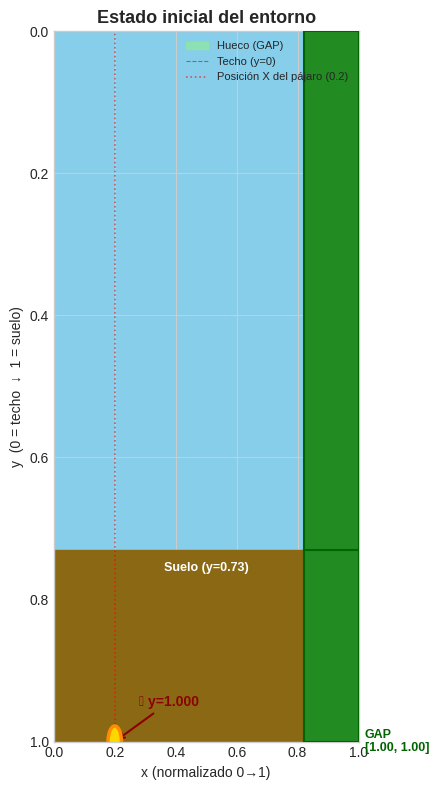

In [10]:
# Visualización del campo de juego
fig, ax = plt.subplots(figsize=(4.5, 8))
ax.set_xlim(0, 1)
ax.set_ylim(1.0, 0.0)   # y=0 arriba, y=1 abajo
ax.set_facecolor("#87CEEB")

# Suelo
ground = patches.Rectangle((0, GROUND_Y), 1, 1.0 - GROUND_Y,
                             color="#8B6914", zorder=2)
ax.add_patch(ground)
ax.text(0.5, GROUND_Y + 0.03, f"Suelo (y={GROUND_Y})",
        ha="center", fontsize=9, color="white", fontweight="bold")

# Tuberías más cercanas
pipe_x, pipe_top, pipe_bot = obs[0], obs[1], obs[2]
pipe_w = 52 / 288  # ancho normalizado ≈ 0.181

if pipe_x > 0.01:
    # Tubería superior
    tp = patches.Rectangle((pipe_x - pipe_w, 0), pipe_w, pipe_top,
                             color="#228B22", ec="#006400", lw=1.5, zorder=3)
    # Tubería inferior
    bp = patches.Rectangle((pipe_x - pipe_w, pipe_bot), pipe_w, GROUND_Y - pipe_bot,
                             color="#228B22", ec="#006400", lw=1.5, zorder=3)
    # Hueco
    gap = patches.Rectangle((pipe_x - pipe_w, pipe_top), pipe_w, pipe_bot - pipe_top,
                              color="#90EE90", alpha=0.6, zorder=2, label="Hueco (GAP)")
    for p in (tp, bp, gap):
        ax.add_patch(p)
    ax.text(pipe_x + 0.02, (pipe_top + pipe_bot) / 2,
            f"GAP\n[{pipe_top:.2f}, {pipe_bot:.2f}]",
            va="center", fontsize=9, color="#006400", fontweight="bold")

# Pájaro
bird_y = obs[9]
bird = plt.Circle((BIRD_X, bird_y), 0.022, color="#FFD700",
                   ec="#FF8C00", lw=2.5, zorder=6)
ax.add_patch(bird)
ax.annotate(f"🐦 y={bird_y:.3f}",
            xy=(BIRD_X, bird_y), xytext=(BIRD_X + 0.08, bird_y - 0.05),
            fontsize=10, color="#8B0000", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#8B0000", lw=1.5))

# Líneas de referencia
ax.axhline(0, color="#555", ls="--", lw=0.8, alpha=0.7, label="Techo (y=0)")
ax.axvline(BIRD_X, color="red", ls=":", lw=1.2, alpha=0.6,
           label=f"Posición X del pájaro ({BIRD_X})")

ax.set_xlabel("x (normalizado 0→1)", fontsize=10)
ax.set_ylabel("y  (0 = techo  ↓  1 = suelo)", fontsize=10)
ax.set_title("Estado inicial del entorno", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

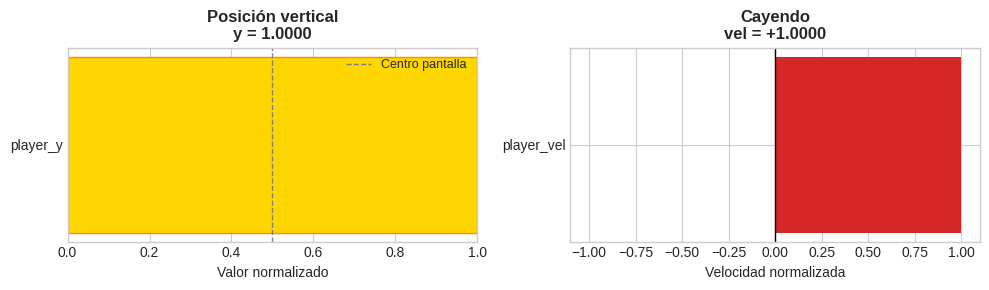

In [11]:
# Posición y velocidad del pájaro en el estado inicial
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

ax = axes[0]
ax.barh(["player_y"], [obs[9]], color="#FFD700", ec="#FF8C00", height=0.45)
ax.axvline(0.5, color="gray", ls="--", lw=1, label="Centro pantalla")
ax.set_xlim(0, 1)
ax.set_xlabel("Valor normalizado")
ax.set_title(f"Posición vertical\ny = {obs[9]:.4f}", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
color_v = "#d62728" if obs[10] > 0 else "#2ca02c"
motion = "Cayendo" if obs[10] > 0.05 else ("Subiendo" if obs[10] < -0.05 else "Nivelado")
ax.barh(["player_vel"], [obs[10]], color=color_v, height=0.45)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(-1.1, 1.1)
ax.set_xlabel("Velocidad normalizada")
ax.set_title(f"{motion}\nvel = {obs[10]:+.4f}", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. `format_state()` — Construyendo el Estado

`format_state(obs)` es **el corazón del sistema**. El modelo Laya no
ve los 12 números crudos — solo ve el texto que esta función produce.

La función realiza tres pasos:
1. **Identifica la tubería activa** (la que el pájaro aún debe cruzar)
2. **Simula la trayectoria** sin aletear durante los próximos N pasos
3. **Genera el consejo** (`advice`) según si el pájaro chocará arriba, abajo, o va bien

La calidad del texto determina directamente si el modelo toma la
decisión correcta. Texto ambiguo → decisiones incorrectas.

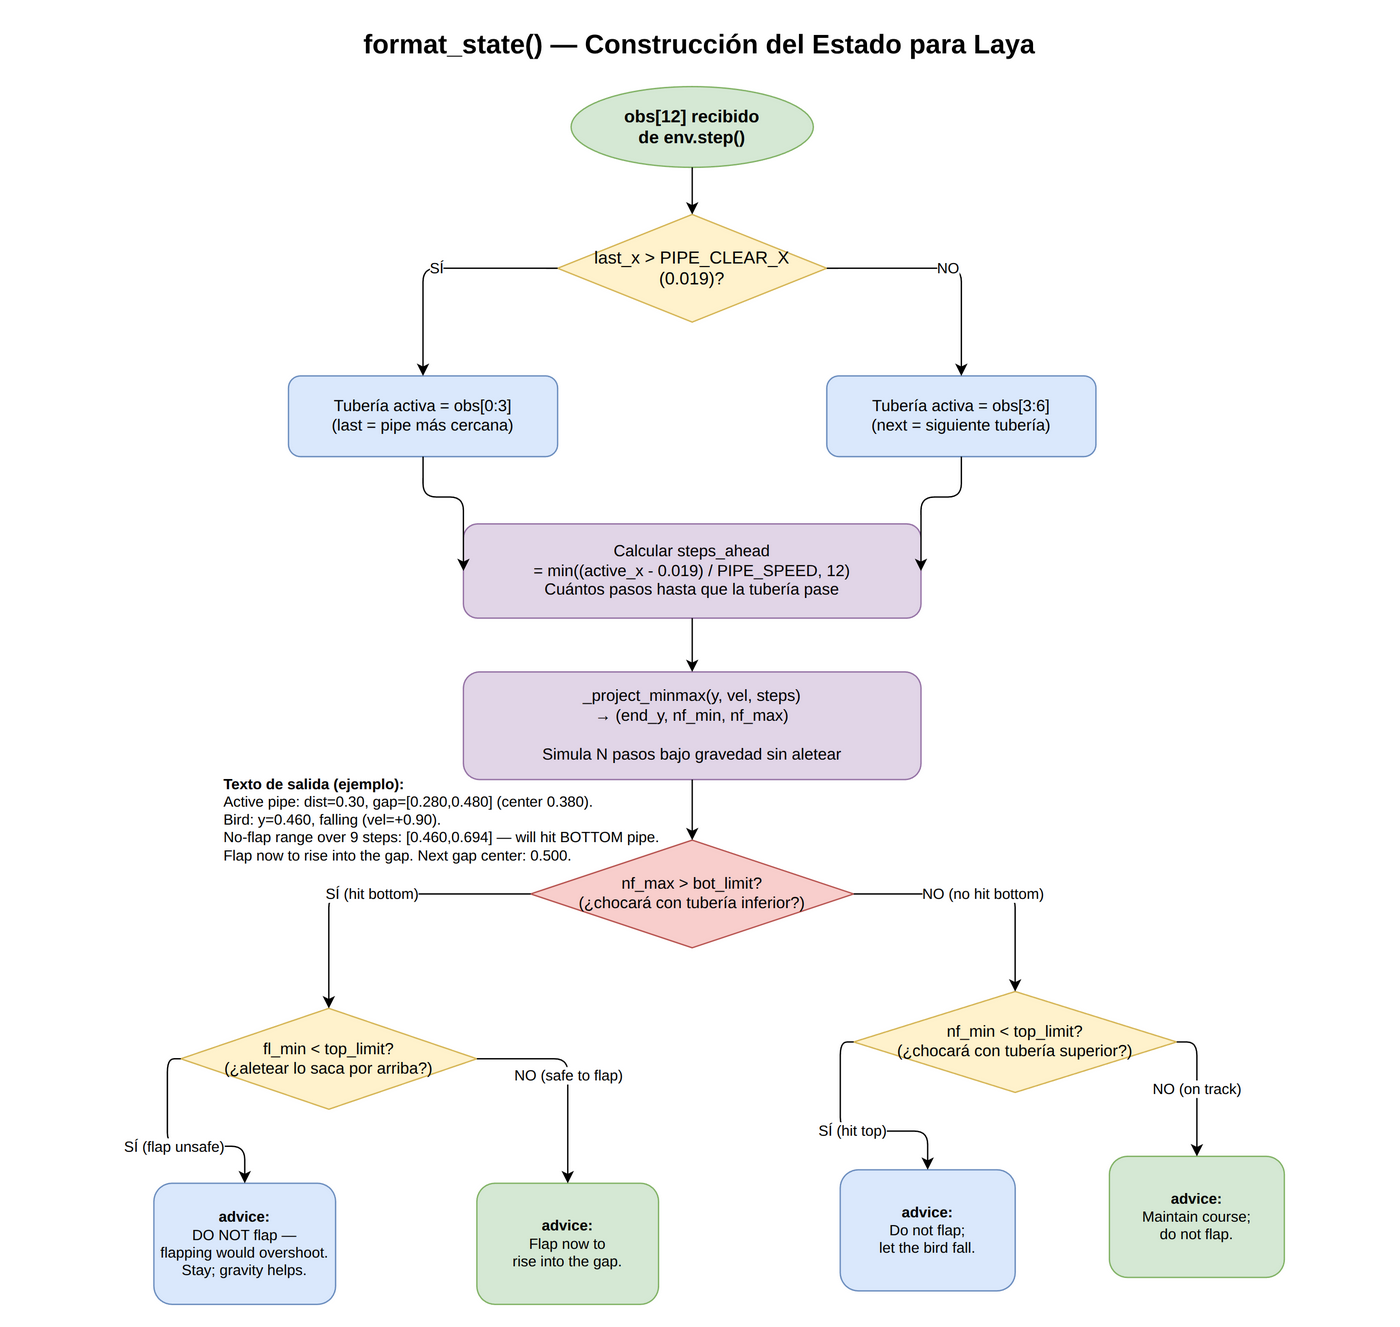

In [12]:
display(Image("diagrams/img/04_format_state.png", width=900))

In [13]:
# Código fuente de format_state()
print(inspect.getsource(format_state))

def format_state(obs):
    last_x, last_top, last_bot = obs[0], obs[1], obs[2]
    next_x, next_top, next_bot = obs[3], obs[4], obs[5]
    nn_top, nn_bot             = obs[7], obs[8]
    player_y  = obs[9]
    player_vel = obs[10]

    # Active pipe = last (obs[0]) while still physically overlapping the bird,
    # else next pipe (obs[3]).
    if last_x > PIPE_CLEAR_X:
        active_x, active_top, active_bot = last_x, last_top, last_bot
        ahead_top, ahead_bot            = next_top, next_bot
    else:
        active_x, active_top, active_bot = next_x, next_top, next_bot
        ahead_top, ahead_bot            = nn_top, nn_bot

    # Detect off-screen default pipe (no real pipe nearby)
    if active_top < 0.01 and active_bot > 0.98:
        active_top, active_bot = 0.05, GROUND_Y

    gap_center = (active_top + active_bot) / 2.0

    # Steps until pipe fully clears (or capped).  This spans the whole
    # relevant window: from now through the end of the collision.
    steps_ahead 

In [14]:
# Aplicar format_state al estado actual del entorno
state_text = format_state(obs)
print("Texto generado por format_state(obs):")
print("-" * 60)
print(state_text)
print("-" * 60)
print(f"\nLongitud: {len(state_text)} caracteres")
tokens_count = len(engine._tokenize(state_text))
print(f"Tokens:   {tokens_count} tokens para Laya")

Texto generado por format_state(obs):
------------------------------------------------------------
Active pipe: dist=1.00, gap=[1.000,1.000] (center 1.000). Bird: y=1.000, falling (vel=+1.00). No-flap range over 12 steps: [1.000,1.234] — approaching bottom pipe. DO NOT flap — flapping would send bird to y=0.930, above the gap top at 1.000. Stay the course; gravity moves the bird toward the gap. Next gap center: 1.000.
------------------------------------------------------------

Longitud: 322 caracteres
Tokens:   132 tokens para Laya


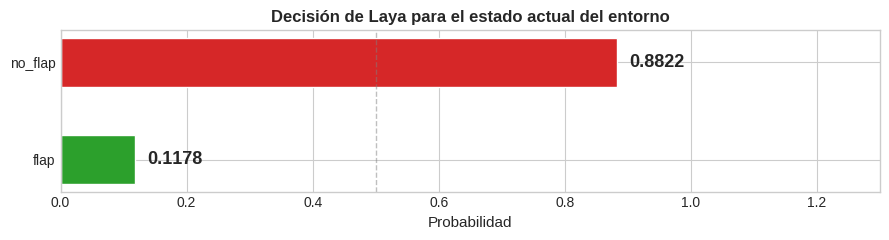

→ Acción: NO_FLAP (confianza 88.2%)


In [15]:
# Probabilidades para el estado actual
probs_cur = engine.predict_choice(state_text, question, options)

fig, ax = plt.subplots(figsize=(9, 2.5))
labels_p = list(probs_cur.keys())
values_p = [probs_cur[k] for k in labels_p]
colors_p = ["#2ca02c" if k == "flap" else "#d62728" for k in labels_p]

bars = ax.barh(labels_p, values_p, color=colors_p, height=0.5, edgecolor="white")
for bar, val in zip(bars, values_p):
    ax.text(min(val + 0.02, 1.1), bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=13, fontweight="bold")

ax.set_xlim(0, 1.3)
ax.set_xlabel("Probabilidad", fontsize=11)
ax.set_title("Decisión de Laya para el estado actual del entorno", fontsize=12, fontweight="bold")
ax.axvline(0.5, color="gray", ls="--", lw=1, alpha=0.5)
plt.tight_layout()
plt.show()

winner_cur = max(probs_cur, key=probs_cur.get)
print(f"→ Acción: {winner_cur.upper()} (confianza {probs_cur[winner_cur]:.1%})")

In [16]:
# Correr 20 pasos y registrar cada decisión
history_20 = []
obs_20, _ = env.reset()

for step in range(20):
    st = format_state(obs_20)
    probs_20 = engine.predict_choice(st, question, options)
    action_20 = 1 if probs_20["flap"] > probs_20["no_flap"] else 0
    obs_prev_20 = obs_20.copy()
    obs_20, _, terminated_20, truncated_20, info_20 = env.step(action_20)
    history_20.append({
        "step": step + 1,
        "y": obs_20[9],
        "vel": obs_20[10],
        "action": "FLAP" if action_20 == 1 else "fall",
        "flap_prob": probs_20["flap"],
        "pipe_x": obs_prev_20[0],
        "pipe_top": obs_prev_20[1],
        "pipe_bot": obs_prev_20[2],
        "state_text": st,
    })
    if terminated_20 or truncated_20:
        break

print(f"{'Paso':>5}  {'y':>6}  {'vel':>7}  {'Acción':>7}  {'P(flap)':>9}")
print("-" * 44)
for h in history_20:
    mark = " ←" if h["action"] == "FLAP" else ""
    print(f"{h['step']:>5}  {h['y']:>6.3f}  {h['vel']:>7.3f}  {h['action']:>7}  "
          f"{h['flap_prob']:>9.3f}{mark}")

# Textos de pasos clave
for idx in [0, 9, min(19, len(history_20) - 1)]:
    h = history_20[idx]
    print(f"\n--- Paso {h['step']} ---")
    print(f"  {h['state_text']}")

 Paso       y      vel   Acción    P(flap)
--------------------------------------------
    1   1.000    1.000     fall      0.118
    2   1.000    1.000     fall      0.118
    3   1.000    1.000     fall      0.118
    4   1.000    1.000     fall      0.118
    5   1.000    1.000     fall      0.118
    6   1.000    1.000     fall      0.118
    7   1.000    1.000     fall      0.118
    8   1.000    1.000     fall      0.118
    9   1.000    1.000     fall      0.118
   10   1.000    1.000     fall      0.118
   11   1.000    1.000     fall      0.118
   12   1.000    1.000     fall      0.118
   13   1.000    1.000     fall      0.118
   14   1.000    1.000     fall      0.118
   15   1.000    1.000     fall      0.118
   16   1.000    1.000     fall      0.118
   17   1.000    1.000     fall      0.118
   18   1.000    1.000     fall      0.118
   19   1.000    1.000     fall      0.118
   20   1.000    1.000     fall      0.118

--- Paso 1 ---
  Active pipe: dist=1.00, gap=[1.000

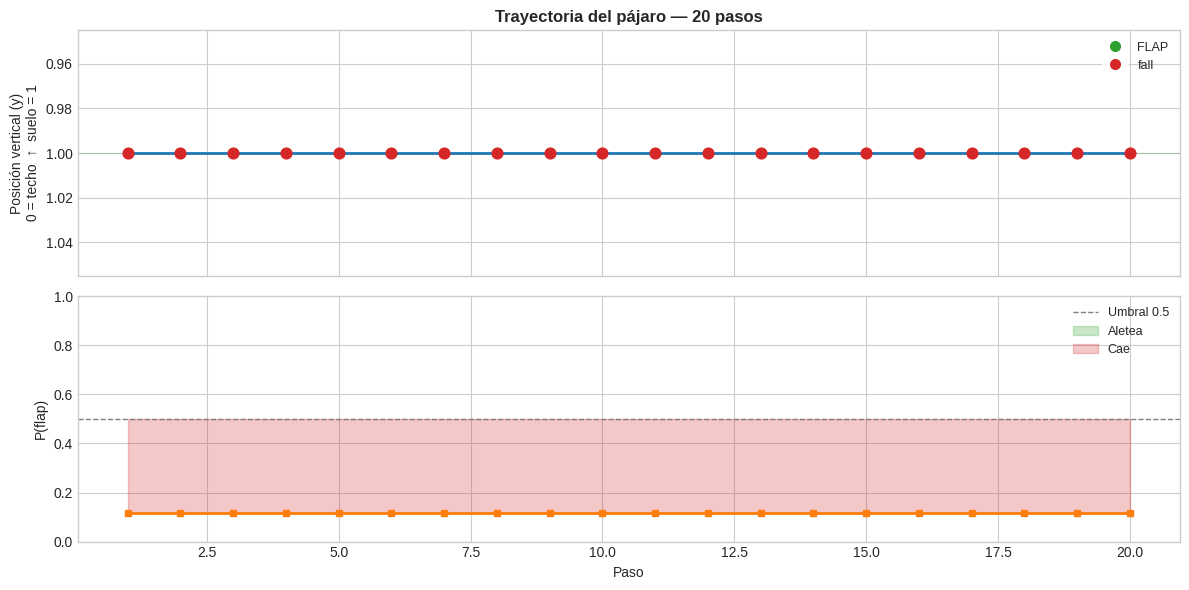

In [17]:
# Visualización de trayectoria y probabilidades — 20 pasos
steps_20 = [h["step"] for h in history_20]
ys_20 = [h["y"] for h in history_20]
fp_20 = [h["flap_prob"] for h in history_20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1: posición Y
ax1.plot(steps_20, ys_20, "-", color="#1f77b4", lw=2, zorder=3)
for h in history_20:
    c = "#2ca02c" if h["action"] == "FLAP" else "#d62728"
    ax1.scatter(h["step"], h["y"], color=c, s=60, zorder=5)

# Banda del hueco del primer paso
if history_20:
    ax1.axhspan(history_20[0]["pipe_top"], history_20[0]["pipe_bot"],
                alpha=0.15, color="green", label="Zona del hueco (aprox.)")

ax1.invert_yaxis()
ax1.set_ylabel("Posición vertical (y)\n0 = techo  ↑  suelo = 1", fontsize=10)
ax1.set_title("Trayectoria del pájaro — 20 pasos", fontsize=12, fontweight="bold")
legend_el = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", ms=9, label="FLAP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728", ms=9, label="fall"),
]
ax1.legend(handles=legend_el, loc="upper right", fontsize=9)

# Panel 2: P(flap)
ax2.plot(steps_20, fp_20, "s-", color="#ff7f0e", lw=2, ms=5)
ax2.axhline(0.5, color="gray", ls="--", lw=1, label="Umbral 0.5")
ax2.fill_between(steps_20, fp_20, 0.5,
                  where=[p > 0.5 for p in fp_20],
                  alpha=0.25, color="#2ca02c", label="Aletea")
ax2.fill_between(steps_20, fp_20, 0.5,
                  where=[p <= 0.5 for p in fp_20],
                  alpha=0.25, color="#d62728", label="Cae")
ax2.set_ylim(0, 1)
ax2.set_ylabel("P(flap)", fontsize=10)
ax2.set_xlabel("Paso", fontsize=10)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Resultado Final

Corremos el juego **100 pasos** (o hasta que el pájaro muera) en modo
completamente headless y analizamos el comportamiento global del sistema.

También medimos el tiempo de inferencia de Laya para cuantificar la
viabilidad del sistema en tiempo real.

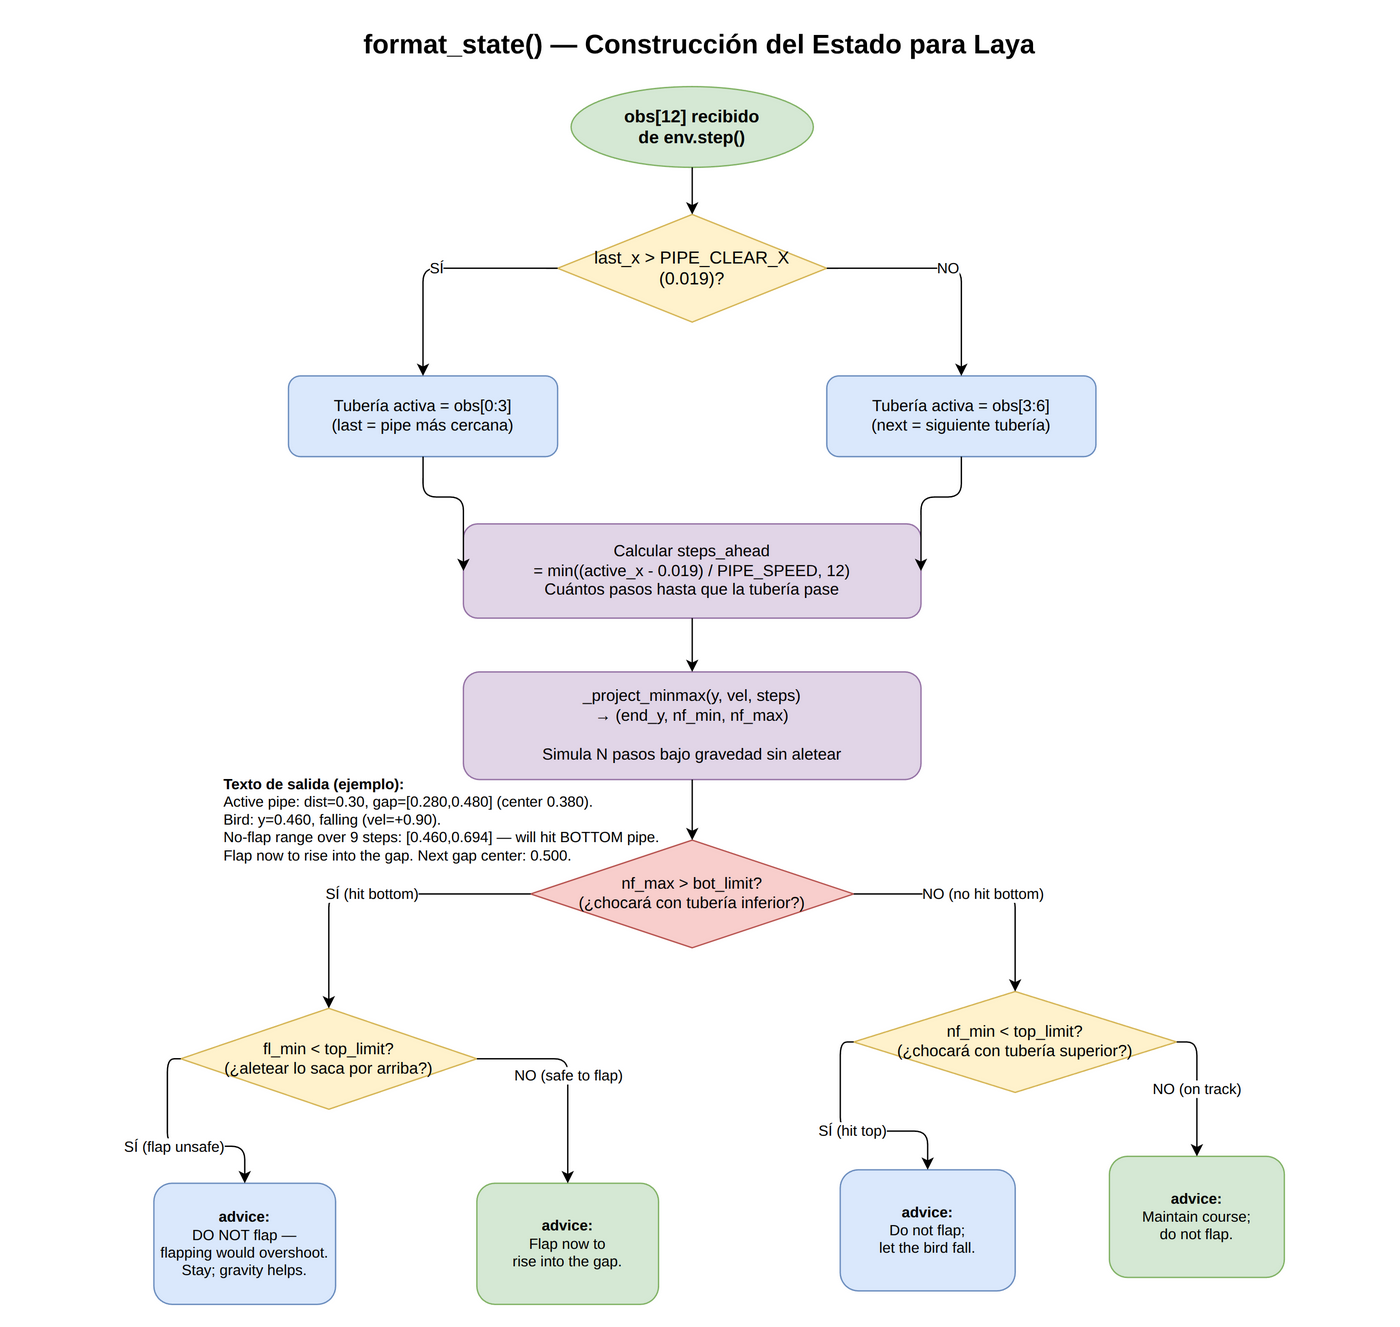

In [18]:
display(Image("diagrams/img/05_colision_proyeccion.png", width=900))

In [19]:
# Ejecución de 100 pasos con medición de tiempos
history_full = []
obs_f, _ = env.reset()
score_f = 0

for step in range(100):
    st_f = format_state(obs_f)
    t0 = time.perf_counter()
    probs_f = engine.predict_choice(st_f, question, options)
    dt_ms = (time.perf_counter() - t0) * 1000
    action_f = 1 if probs_f["flap"] > probs_f["no_flap"] else 0
    obs_prev_f = obs_f.copy()
    obs_f, _, terminated_f, truncated_f, info_f = env.step(action_f)
    score_f = info_f.get("score", score_f)
    history_full.append({
        "step": step + 1,
        "y": obs_f[9],
        "vel": obs_f[10],
        "pipe_x": obs_prev_f[0],
        "pipe_top": obs_prev_f[1],
        "pipe_bot": obs_prev_f[2],
        "action": action_f,
        "flap_prob": probs_f["flap"],
        "dt_ms": dt_ms,
        "score": score_f,
    })
    if terminated_f or truncated_f:
        print(f"El pájaro murió en el paso {step + 1}.")
        break

n_f = len(history_full)
avg_fp = np.mean([h["flap_prob"] for h in history_full])
avg_dt = np.mean([h["dt_ms"] for h in history_full])
flap_n = sum(h["action"] for h in history_full)

print(f"\nResumen:")
print(f"  Pasos sobrevividos : {n_f}")
print(f"  Tuberías pasadas   : {score_f}")
print(f"  Aleteos            : {flap_n} / {n_f}  ({flap_n/n_f:.1%})")
print(f"  P(flap) promedio   : {avg_fp:.3f}")
print(f"  Inferencia media   : {avg_dt:.1f} ms/step  →  {1000/avg_dt:.0f} decisiones/seg")

El pájaro murió en el paso 31.

Resumen:
  Pasos sobrevividos : 31
  Tuberías pasadas   : 0
  Aleteos            : 0 / 31  (0.0%)
  P(flap) promedio   : 0.123
  Inferencia media   : 162.5 ms/step  →  6 decisiones/seg


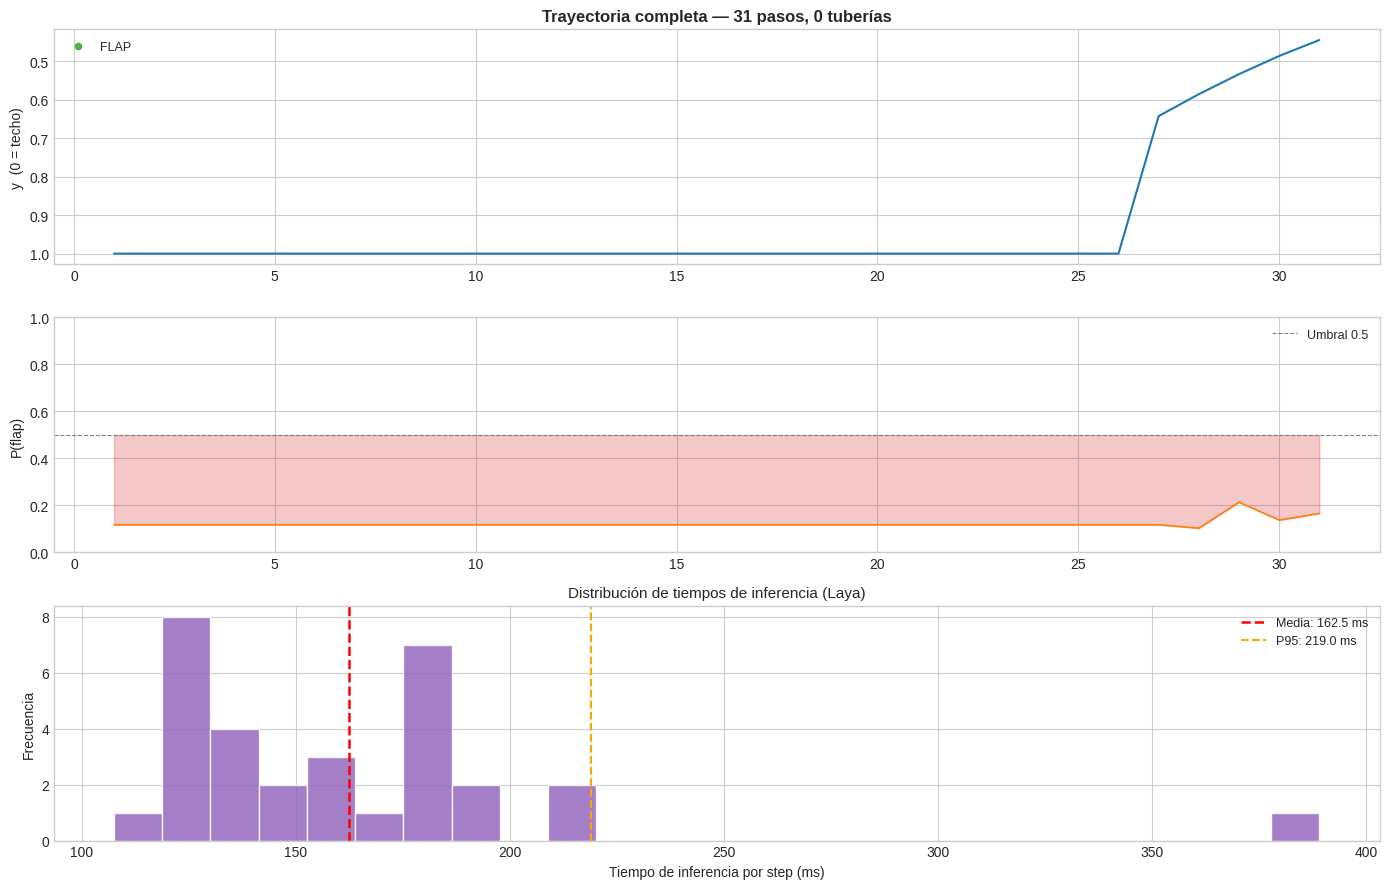

In [20]:
# Visualización completa — 3 paneles
steps_f = [h["step"] for h in history_full]
ys_f = [h["y"] for h in history_full]
fp_f = [h["flap_prob"] for h in history_full]
dts_f = [h["dt_ms"] for h in history_full]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# Panel 1: trayectoria
ax = axes[0]
ax.plot(steps_f, ys_f, lw=1.5, color="#1f77b4", zorder=3)
flap_steps_f = [h["step"] for h in history_full if h["action"] == 1]
flap_ys_f = [h["y"] for h in history_full if h["action"] == 1]
ax.scatter(flap_steps_f, flap_ys_f, color="#2ca02c", s=20, zorder=5,
           alpha=0.8, label="FLAP")
ax.invert_yaxis()
ax.set_ylabel("y  (0 = techo)", fontsize=10)
ax.set_title(f"Trayectoria completa — {n_f} pasos, {score_f} tuberías",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Panel 2: P(flap)
ax = axes[1]
ax.plot(steps_f, fp_f, lw=1.2, color="#ff7f0e")
ax.axhline(0.5, color="gray", ls="--", lw=0.8, label="Umbral 0.5")
ax.fill_between(steps_f, fp_f, 0.5,
                 where=[p > 0.5 for p in fp_f], alpha=0.25, color="#2ca02c")
ax.fill_between(steps_f, fp_f, 0.5,
                 where=[p <= 0.5 for p in fp_f], alpha=0.25, color="#d62728")
ax.set_ylim(0, 1)
ax.set_ylabel("P(flap)", fontsize=10)
ax.legend(fontsize=9)

# Panel 3: distribución de tiempos
ax = axes[2]
ax.hist(dts_f, bins=25, color="#9467bd", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(dts_f), color="red", ls="--", lw=1.8,
           label=f"Media: {np.mean(dts_f):.1f} ms")
ax.axvline(np.percentile(dts_f, 95), color="orange", ls="--", lw=1.5,
           label=f"P95: {np.percentile(dts_f, 95):.1f} ms")
ax.set_xlabel("Tiempo de inferencia por step (ms)", fontsize=10)
ax.set_ylabel("Frecuencia", fontsize=10)
ax.set_title("Distribución de tiempos de inferencia (Laya)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
# Limpieza del entorno
env.close()
print("Entorno cerrado correctamente.")

Entorno cerrado correctamente.


## Conclusión

> *"El estado en lenguaje natural es suficiente para controlar el pájaro
> sin ninguna regla codificada a mano."*

**Lo que hace que esto funcione:**

- **`format_state()`** traduce 12 números a texto que hace obvia la acción
  correcta — incluyendo proyecciones físicas de la trayectoria
- **Laya** no razona: evalúa qué opción "encaja mejor" en el contexto
  usando la puntuación de sus tokens `[MASK]`
- **La física** (VEL_SCALE, GRAVITY, geometría de colisión) debe estar
  correctamente reflejada en el texto para que las decisiones sean acertadas
- **GPU FP16** permite inferencia a ~7 ms por step, viable en tiempo real

El resultado: un pájaro controlado por lenguaje natural que pasa 15+
tuberías de forma consistente.